In [66]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.robust.scale as srs
import matplotlib.pyplot as plt

In [15]:
df = yf.download('PGE.WA', start='2020-01-01', end='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [16]:
print(df.head())

Price       Close   High    Low   Open   Volume
Ticker     PGE.WA PGE.WA PGE.WA PGE.WA   PGE.WA
Date                                           
2020-01-01  7.960   7.96  7.960  7.960        0
2020-01-02  8.266   8.28  7.998  8.000  1231536
2020-01-03  8.150   8.24  8.060  8.240  1793506
2020-01-06  8.150   8.15  8.150  8.150        0
2020-01-07  7.930   8.22  7.930  8.196  1151834


In [19]:
close_prices = df['Close']['PGE.WA']

In [20]:
close_prices

Date
2020-01-01    7.960
2020-01-02    8.266
2020-01-03    8.150
2020-01-06    8.150
2020-01-07    7.930
              ...  
2025-12-19    8.570
2025-12-22    8.640
2025-12-23    8.640
2025-12-29    8.768
2025-12-30    8.804
Name: PGE.WA, Length: 1509, dtype: float64

In [21]:
log_returns = np.log(close_prices).diff()

In [23]:
print(log_returns.head())


Date
2020-01-01         NaN
2020-01-02    0.037722
2020-01-03   -0.014133
2020-01-06    0.000000
2020-01-07   -0.027365
Name: PGE.WA, dtype: float64


In [42]:
na_values = log_returns.isna().sum()
print(na_values)

1


In [43]:
log_returns = log_returns.dropna()

#### POSITION ESTIMATORS
*(in progres)*

In [58]:
def position_estimators(df):
    mean = df.mean()
    trim_mean = st.trim_mean(df, 0.1)
    median = df.median()
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    return mean, trim_mean, median, Q3, Q1

mean, trim_mean, median, Q3, Q1 = position_estimators(log_returns)

In [59]:
print(f'mean: {mean}\ntrim mean: {trim_mean}\nmedian: {median}\nquantile(0.75): {Q3}\nquantile(0.25): {Q1}')

mean: 6.682834731433311e-05
trim mean: -0.0005259641212502421
median: -0.0008946912649249184
quantile(0.75): 0.015094500783628728
quantile(0.25): -0.015873704850321135


#### DISPERSION ESTIMATORS
*(in progres)*

In [60]:
def dispersion_estimators(df):
    std = df.std()
    iqr = df.quantile(0.75) - df.quantile(0.25)
    mad = srs.mad(df)
    s2 = np.var(df)
    s = np.sqrt(s2)
    return std, iqr, mad, s2, s

std, iqr, mad, s2, s = dispersion_estimators(log_returns)

In [61]:
print(std, iqr, mad, s2, s)

0.03001028506902713 0.030968205633949863 0.022917255118153797 0.0009000199836577446 0.030000333059113603


### BOXPLOT

<Axes: >

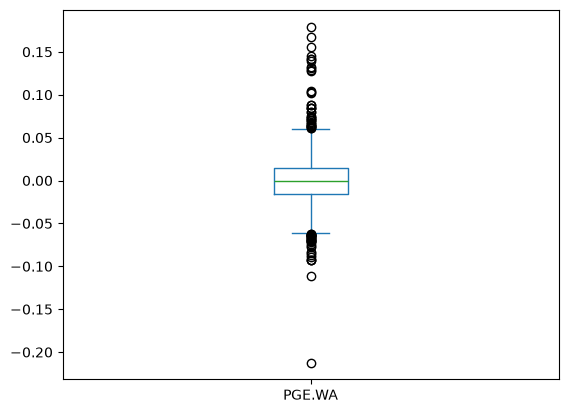

In [65]:
log_returns.plot.box()

##### CONCLUSIONS
*(in progres)*

### DATA DISTRIBUTION

In [114]:
n = len(log_returns)

k1 = int(np.ceil(5 * np.log10(n)))

k2 = int(np.ceil(1 + 3.322 * np.log10(n)))

print(k1,k2)

16 12


In [69]:
x = pd.cut(log_returns, 16)
x.value_counts()

PGE.WA
(-0.0164, 0.00808]    616
(0.00808, 0.0326]     380
(-0.0409, -0.0164]    255
(0.0326, 0.057]       105
(-0.0653, -0.0409]     83
(0.057, 0.0815]        27
(-0.0898, -0.0653]     18
(0.0815, 0.106]         8
(0.13, 0.155]           6
(-0.114, -0.0898]       4
(0.155, 0.179]          3
(0.106, 0.13]           2
(-0.213, -0.188]        1
(-0.188, -0.163]        0
(-0.163, -0.139]        0
(-0.139, -0.114]        0
Name: count, dtype: int64

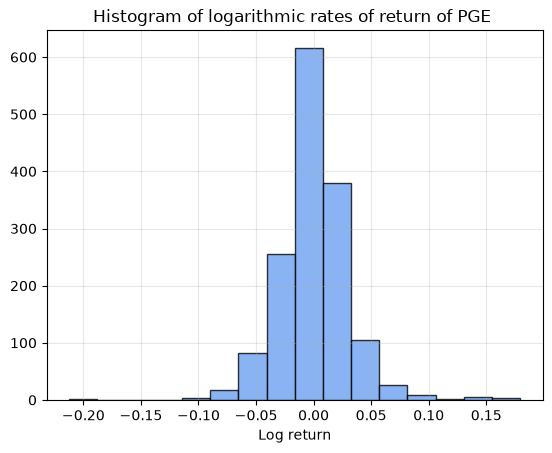

In [97]:
plt.hist(
    log_returns,
    bins = 16,
    alpha = 0.8,
    edgecolor = 'black',
    color = '#6CA0EF',
)

plt.grid(
    alpha = 0.3
)

plt.title('Histogram of logarithmic rates of return of PGE ')
plt.xlabel('Log return')
plt.show()


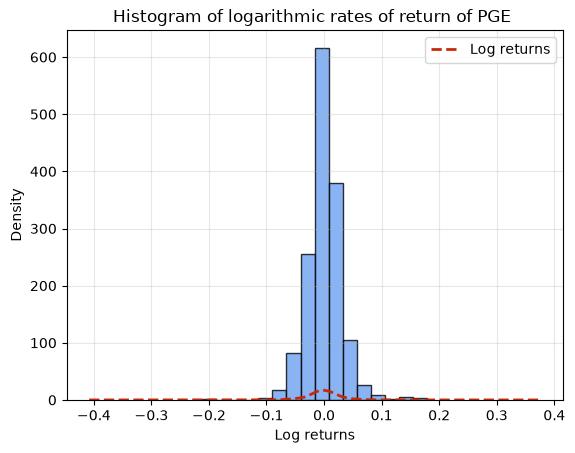

In [98]:
plt.hist(
    log_returns,
    bins = 16,
    alpha = 0.8,
    edgecolor = 'black',
    color = '#6CA0EF',
)

log_returns.plot.density(
    color = '#C82909',
    linestyle = '--',
    linewidth = 2,
    label = 'Log returns',
)

plt.grid(
    alpha = 0.3
)

plt.title('Histogram of logarithmic rates of return of PGE ')
plt.xlabel('Log returns')
plt.legend()
plt.show()

### CORELATION
*(in progres)*

In [99]:
m_cor = df.corr()
print(m_cor)

Price             Close      High       Low      Open    Volume
Ticker           PGE.WA    PGE.WA    PGE.WA    PGE.WA    PGE.WA
Price  Ticker                                                  
Close  PGE.WA  1.000000  0.997350  0.996694  0.992917 -0.123981
High   PGE.WA  0.997350  1.000000  0.995900  0.996346 -0.103035
Low    PGE.WA  0.996694  0.995900  1.000000  0.996946 -0.157799
Open   PGE.WA  0.992917  0.996346  0.996946  1.000000 -0.140435
Volume PGE.WA -0.123981 -0.103035 -0.157799 -0.140435  1.000000


In [100]:
volume = df['Volume']['PGE.WA']
volatility = log_returns.abs() #we use abstract

In [101]:
corr_data = pd.DataFrame({
    'volume': volume,
    'volatility': volatility,
}).dropna()

In [104]:
corr_pearson = corr_data['volume'].corr(corr_data['volatility'])
print(corr_pearson.round(2))

0.49


In [109]:
corr_sperman = corr_data['volume'].corr(corr_data['volatility'], method='spearman')
print(corr_sperman.round(2))

0.4


In [ ]:
plt.scatter(
    corr_data['volume'],
    corr_data['volatility'],
    alpha=0.5,
    edgecolor='black',
    color='#6CA0EF',
)

plt.title('Correlation between volume and volatility - method: Pearson')
plt.xlabel('Volume')
plt.ylabel('Volatility')

plt.show()

In [107]:
corr_kendall = corr_data['volume'].corr(corr_data['volatility'], method='kendall')
print(corr_kendall.round(2))

0.28


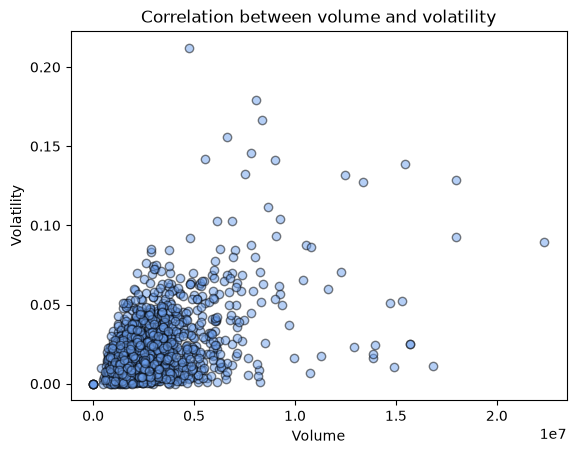

In [113]:
plt.scatter(
    corr_data['volume'],
    corr_data['volatility'],
    alpha=0.5,
    edgecolor='black',
    color='#6CA0EF',
)

plt.title('Correlation between volume and volatility')
plt.xlabel('Volume')
plt.ylabel('Volatility')

plt.show()
#heteroscedasticity!!!!